In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import networkx as nx
from scipy import stats
import umap.umap_ as umap 
import plotly.express as px
from sklearn.cluster import HDBSCAN
from scipy.stats import fisher_exact
from matplotlib import pyplot as plt
from sklearn.decomposition import PCA
from sklearn.metrics import roc_auc_score
from matplotlib.ticker import FuncFormatter
from scipy.spatial.distance import squareform
from sklearn.neighbors import kneighbors_graph
from scipy.stats import mannwhitneyu, ttest_ind
from sklearn.cluster import AgglomerativeClustering

2024-11-10 16:39:24.354689: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2024-11-10 16:39:24.571355: I external/local_tsl/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2024-11-10 16:39:25.405398: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-11-10 16:39:25.405561: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-11-10 16:39:25.582752: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to

In [2]:
dists = pd.read_csv("/mnt/isilon/tan_lab/yanga11/CytoIntermediates/HyperGlioma/Nolan/NolanInstances/neighborhood_distance_matrix_pHGG_NolanInstances.csv")
dists.set_index('Unnamed: 0', inplace=True)
dists /= 20000
dists.head()

,Nolan_7316-161_1-0,Nolan_7316-161_1-1,Nolan_7316-161_1-10,Nolan_7316-161_1-11,Nolan_7316-161_1-12,Nolan_7316-161_1-2,Nolan_7316-161_1-3,Nolan_7316-161_1-4,Nolan_7316-161_1-5,Nolan_7316-161_1-6,...,Nolan_7316-942_9-86,Nolan_7316-942_9-87,Nolan_7316-942_9-88,Nolan_7316-942_9-89,Nolan_7316-942_9-9,Nolan_7316-942_9-90,Nolan_7316-942_9-91,Nolan_7316-942_9-92,Nolan_7316-942_9-93,Nolan_7316-942_9-94
Unnamed: 0,,,,,,,,,,,,,,,,,,,,,
Nolan_7316-161_1-0,0.00000,0.22165,0.21515,0.18985,0.24385,0.24235,0.26185,0.18320,0.25385,0.55605,...,0.39005,0.44205,0.52450,0.52560,0.50285,0.45480,0.51285,0.40750,0.51800,0.44995
Nolan_7316-161_1-1,0.22165,0.00000,0.24450,0.15620,0.13770,0.22540,0.22810,0.23605,0.22270,0.61610,...,0.36130,0.41860,0.48615,0.45745,0.39610,0.39985,0.44800,0.32895,0.48555,0.38410
Nolan_7316-161_1-10,0.21515,0.24450,0.00000,0.24820,0.28890,0.29400,0.28660,0.20745,0.31840,0.60340,...,0.31990,0.35760,0.37305,0.45005,0.44460,0.37605,0.37210,0.32585,0.39455,0.33980
Nolan_7316-161_1-11,0.18985,0.15620,0.24820,0.00000,0.18640,0.21100,0.28230,0.20535,0.26110,0.59330,...,0.35430,0.41780,0.49945,0.50115,0.40650,0.43505,0.44760,0.35735,0.49065,0.40390
Nolan_7316-161_1-12,0.24385,0.13770,0.28890,0.18640,0.00000,0.19360,0.27190,0.28285,0.24420,0.59620,...,0.33930,0.40550,0.45805,0.44535,0.38210,0.37355,0.41910,0.30335,0.46245,0.38460


In [ ]:
# Perform hierarchical clustering using AgglomerativeClustering
clustering = AgglomerativeClustering(distance_threshold=None, metric='precomputed', linkage='complete')
clustering.fit(dists)
labels = clustering.labels_
sample_names = dists.columns
cluster_df = pd.DataFrame({'Sample': sample_names, 'Cluster': labels})
g = sns.clustermap(dists, row_cluster=True,
                    col_cluster=True, xticklabels=False, yticklabels=False, figsize=(10, 10), cmap='rocket')
g.fig.subplots_adjust(left=0.2, top=0.8)
g.ax_cbar.set_position((1, .2, .03, .4))
#g.savefig('clustermap_nolaninstances.png', dpi=600)


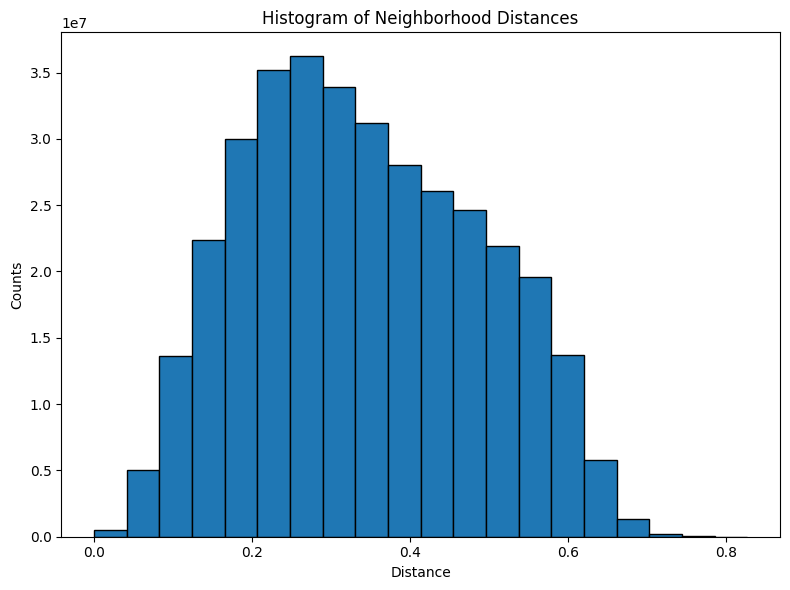

In [3]:
flatdists = dists.values.flatten()
fig, ax = plt.subplots(figsize=(8, 6))

ax.hist(flatdists, bins=20, edgecolor='black')
ax.set_title('Histogram of Neighborhood Distances')
ax.set_xlabel('Distance')
ax.set_ylabel('Counts')  

fig.tight_layout()

#plt.savefig('Histogram_of_Neighborhood_Distances.png')
plt.show()


In [4]:
value = 0.5
percentile = stats.percentileofscore(flatdists, value)
print(f"The value {value} is at the {percentile:.2f}th percentile.")

The value 0.5 is at the 82.78th percentile.


In [5]:
treatment_map = {"7316-4740":"Pre-Treatment","7316-4337":"Post-Treatment","7316-339":"Pre-Treatment",
                 "7316-942":"Post-Treatment","7316-161":"Pre-Treatment","7316-5335":"Post-Treatment",
                 "7316-6477":"Post-Treatment","7316-3058":"Post-Treatment", "7316-371":"Post-Treatment",
                 "7316-5928":"Post-Treatment", "7316-7622":"Post-Treatment"}


df = pd.DataFrame({"full": dists.columns})

# Split the column names by "_"
split_columns = df["full"].str.split("_", expand=True)

# Find the maximum number of parts in any split
max_parts = split_columns.shape[1]

# Extract 'sample' from the split columns (assume it's the second part)
#df["tile"] = split_columns[0] +"_"+split_columns[2]
df["sample"]=split_columns[1]

# Extract 'neighborhood' from the last part of the split columns
df["neighborhood"] = split_columns.iloc[:, -1]
df["neighborhood"].fillna(split_columns.iloc[:, -2], inplace=True)

# Combine 'sample' and 'neighborhood' to form 'image_neigborhood'
df["image_neigborhood"] = df["sample"] + "_" + df["neighborhood"]

df["treatment"] = df["sample"].map(treatment_map)

df


/var/tmp/ipykernel_3113446/3188775821.py:21: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["neighborhood"].fillna(split_columns.iloc[:, -2], inplace=True)


,full,sample,neighborhood,image_neigborhood,treatment
0,Nolan_7316-161_1-0,7316-161,1-0,7316-161_1-0,Pre-Treatment
1,Nolan_7316-161_1-1,7316-161,1-1,7316-161_1-1,Pre-Treatment
2,Nolan_7316-161_1-10,7316-161,1-10,7316-161_1-10,Pre-Treatment
3,Nolan_7316-161_1-11,7316-161,1-11,7316-161_1-11,Pre-Treatment
4,Nolan_7316-161_1-12,7316-161,1-12,7316-161_1-12,Pre-Treatment
...,...,...,...,...,...
18684,Nolan_7316-942_9-90,7316-942,9-90,7316-942_9-90,Post-Treatment
18685,Nolan_7316-942_9-91,7316-942,9-91,7316-942_9-91,Post-Treatment
18686,Nolan_7316-942_9-92,7316-942,9-92,7316-942_9-92,Post-Treatment
18687,Nolan_7316-942_9-93,7316-942,9-93,7316-942_9-93,Post-Treatment


In [6]:
reducer = umap.UMAP(metric="precomputed", random_state=42)
reduced = reducer.fit_transform(dists.values)
df["UMAP 1"] = reduced[:, 0]
df["UMAP 2"] = reduced[:, 1]

/home/yanga11/.local/lib/python3.10/site-packages/umap/umap_.py:1858: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
/home/yanga11/.local/lib/python3.10/site-packages/umap/umap_.py:1945: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


In [7]:
pca = PCA(n_components=5)
reduced = pca.fit_transform(dists.values)
df["PCA 1"] = reduced[:, 0]
df["PCA 2"] = reduced[:, 1]
df["PCA 3"] = reduced[:, 2]
df["PCA 4"] = reduced[:, 3]
df["PCA 5"] = reduced[:, 4]

loading_matrix = pca.components_.T
explained_variance_ratio = pca.explained_variance_ratio_
print(explained_variance_ratio)

squared_loadings = loading_matrix ** 2
percent_contribution = squared_loadings / np.sum(squared_loadings, axis=0)

[0.71878965 0.10174663 0.061803   0.04203159 0.02912765]


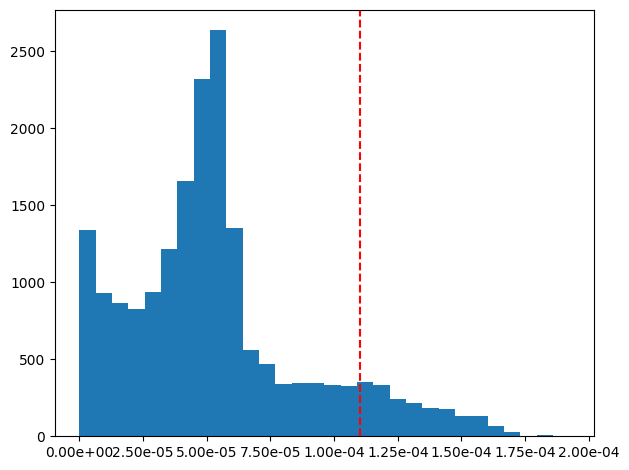

In [8]:
from matplotlib.ticker import FuncFormatter
# Your code to compute `top_features_contribution`
top_features_contribution = np.sum(percent_contribution[:, [0, 2]], axis=1)
top_features_contribution /= np.sum(top_features_contribution)

plt.hist(top_features_contribution, bins=30)

formatter = FuncFormatter(lambda x, _: f'{x:.2e}') 
plt.gca().xaxis.set_major_formatter(formatter)
plt.axvline(x=1.1e-04, color='r', linestyle='--')

plt.tight_layout()
plt.show()

In [12]:
# Filter neighborhoods to top contributors
top_features_contribution_plot=top_features_contribution
top_features_contribution_plot[top_features_contribution_plot > 1.1e-04] = 1
top_features_contribution_plot[top_features_contribution_plot < 1.1e-04] = 0
np.sum(top_features_contribution_plot)

1828.0

<Axes: xlabel='UMAP 1', ylabel='UMAP 2'>

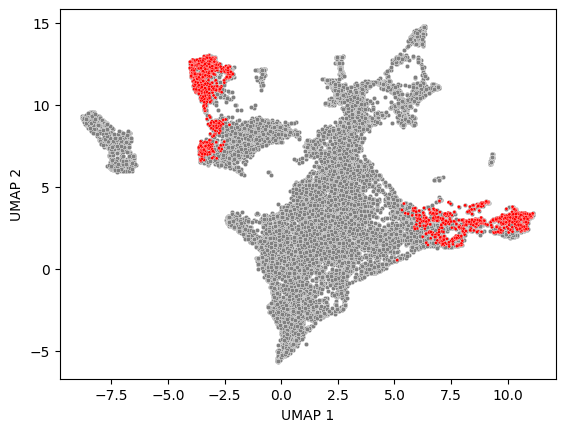

In [13]:
# Show top neighborhoods on UMAP
df["plot"] = top_features_contribution_plot
sns.scatterplot(df, x="UMAP 1", y = "UMAP 2",s=10,c='grey')
sns.scatterplot(df, x="UMAP 1", y = "UMAP 2", alpha=df["plot"],s=5,c='red')

In [13]:
df["contribution"] = top_features_contribution
filtered_samples = df.loc[df['plot'] == 1, 'full'].tolist()
filtered_dists = dists.loc[filtered_samples, filtered_samples]
filtered_dists.head()

,Nolan_7316-161_10-0,Nolan_7316-161_10-1,Nolan_7316-161_10-10,Nolan_7316-161_10-11,Nolan_7316-161_10-12,Nolan_7316-161_10-13,Nolan_7316-161_10-14,Nolan_7316-161_10-15,Nolan_7316-161_10-16,Nolan_7316-161_10-18,...,Nolan_7316-942_5-77,Nolan_7316-942_5-78,Nolan_7316-942_5-8,Nolan_7316-942_5-80,Nolan_7316-942_5-84,Nolan_7316-942_5-86,Nolan_7316-942_5-89,Nolan_7316-942_5-9,Nolan_7316-942_5-91,Nolan_7316-942_5-95
Unnamed: 0,,,,,,,,,,,,,,,,,,,,,
Nolan_7316-161_10-0,0.00000,0.13665,0.33765,0.23945,0.20165,0.34235,0.26410,0.35000,0.29615,0.34480,...,0.15210,0.23975,0.23655,0.27850,0.34045,0.25935,0.21675,0.18995,0.17280,0.27295
Nolan_7316-161_10-1,0.13665,0.00000,0.36350,0.19430,0.11940,0.26590,0.22515,0.23525,0.22880,0.27485,...,0.19235,0.26350,0.24590,0.27795,0.33960,0.27260,0.21140,0.22880,0.22385,0.27830
Nolan_7316-161_10-10,0.33765,0.36350,0.00000,0.33990,0.34880,0.29430,0.34715,0.28355,0.34600,0.26135,...,0.31485,0.34970,0.24380,0.30195,0.27680,0.28980,0.25620,0.32130,0.38195,0.32470
Nolan_7316-161_10-11,0.23945,0.19430,0.33990,0.00000,0.13090,0.26240,0.14315,0.28095,0.21940,0.32445,...,0.21075,0.37990,0.25970,0.31845,0.34820,0.33970,0.25690,0.29200,0.26485,0.33150
Nolan_7316-161_10-12,0.20165,0.11940,0.34880,0.13090,0.00000,0.25510,0.18445,0.19505,0.16600,0.27065,...,0.19135,0.31700,0.24130,0.29905,0.32970,0.31400,0.23950,0.25860,0.23635,0.30520


In [14]:
# Cluster top contributing neighborhoods
clustering = HDBSCAN(min_cluster_size=15, metric="euclidean").fit(filtered_dists)
filtered_dists["cluster"] = clustering.labels_
print(set(clustering.labels_))
cluster_df = df.merge(filtered_dists[["cluster"]],left_on="full",right_index=True,how="outer")

{0, 1}


In [ ]:
cluster_df.to_csv("/mnt/isilon/tan_lab/yanga11/CytoIntermediates/HyperGlioma/NolanInstancesProcessed.csv")

In [ ]:
#This clustering returns 3 clusters, one of which is much smaller than the other two and is noise
filtered_samples = cluster_df.loc[cluster_df['cluster'] == 0, 'full'].tolist()
filtered_dists = dists.loc[filtered_samples, filtered_samples]
filtered_dists.head()
# Perform hierarchical clustering using AgglomerativeClustering
clustering = AgglomerativeClustering(n_clusters=3, distance_threshold=None, metric='precomputed', linkage='complete')
clustering.fit(filtered_dists)

# Get the cluster labels
labels = clustering.labels_

# Use the index of the distance matrix as sample names
sample_names = filtered_dists.columns  # or dists.columns, depending on your DataFrame

# Create a DataFrame with sample names and their corresponding cluster labels
subcluster_df = pd.DataFrame({'Sample': sample_names, 'Cluster': labels})

# Save separate CSV files for each cluster
for cluster in np.unique(labels):
    subcluster_samples = subcluster_df[subcluster_df['Cluster'] == cluster]
    subcluster_samples.to_csv(f'cluster0_{cluster}.csv', index=False)

# Plot the clustermap using seaborn
g = sns.clustermap(dists, row_cluster=True,
                    col_cluster=True, xticklabels=False, yticklabels=False, figsize=(10, 10), cmap='rocket')

# Customize labels and colorbar
plt.setp(g.ax_heatmap.get_xticklabels(), rotation=90, fontsize=7)  # Adjust fontsize as needed
plt.setp(g.ax_heatmap.get_yticklabels(), fontsize=7)  # Adjust fontsize as needed

g.fig.subplots_adjust(left=0.2, top=0.8)
g.ax_cbar.set_position((1, .2, .03, .4))

# Save the plot
#g.savefig('clustermap_nolaninstances_c0.png', dpi=600)


In [ ]:
#This clustering returns 3 clusters, one of which is much smaller than the other two and is noise
filtered_samples = cluster_df.loc[cluster_df['cluster'] == 1, 'full'].tolist()
filtered_dists = dists.loc[filtered_samples, filtered_samples]
filtered_dists.head()
# Perform hierarchical clustering using AgglomerativeClustering
clustering = AgglomerativeClustering(n_clusters=3, distance_threshold=None, metric='precomputed', linkage='complete')
clustering.fit(filtered_dists)

# Get the cluster labels
labels = clustering.labels_

# Use the index of the distance matrix as sample names
sample_names = filtered_dists.columns  # or dists.columns, depending on your DataFrame

# Create a DataFrame with sample names and their corresponding cluster labels
subcluster_df = pd.DataFrame({'Sample': sample_names, 'Cluster': labels})

# Save separate CSV files for each cluster
for cluster in np.unique(labels):
    subcluster_samples = subcluster_df[subcluster_df['Cluster'] == cluster]
    subcluster_samples.to_csv(f'cluster1_{cluster}.csv', index=False)

# Plot the clustermap using seaborn
g = sns.clustermap(dists, row_cluster=True,
                    col_cluster=True, xticklabels=False, yticklabels=False, figsize=(10, 10), cmap='rocket')

# Customize labels and colorbar
plt.setp(g.ax_heatmap.get_xticklabels(), rotation=90, fontsize=7)  # Adjust fontsize as needed
plt.setp(g.ax_heatmap.get_yticklabels(), fontsize=7)  # Adjust fontsize as needed

g.fig.subplots_adjust(left=0.2, top=0.8)
g.ax_cbar.set_position((1, .2, .03, .4))

# Save the plot
#g.savefig('clustermap_nolaninstances_c1.png', dpi=600)


/tmp/ipykernel_2035928/2995010077.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


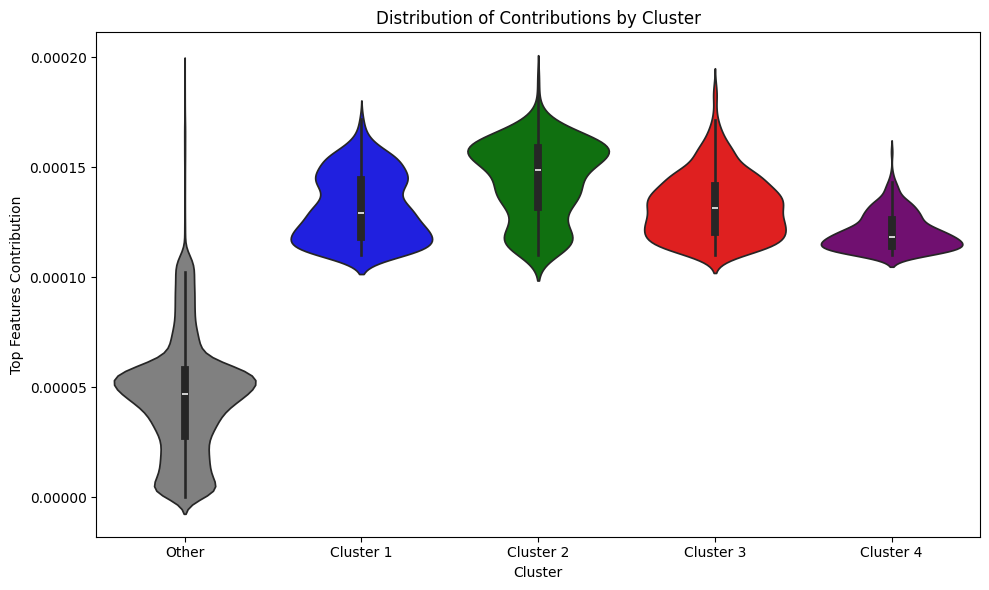

In [14]:
loading_matrix = pca.components_.T
squared_loadings = loading_matrix ** 2
percent_contribution = squared_loadings / np.sum(squared_loadings, axis=0)
top_features_contribution = np.sum(percent_contribution[:, [0, 2]], axis=1)
top_features_contribution /= np.sum(top_features_contribution)

# Add sample names from dists index or columns to create a DataFrame
sample_names = dists.index  # Use index or columns depending on your data
top_features_contribution_df = pd.DataFrame({
    "SampleName": sample_names,
    "Contribution": top_features_contribution
})

# Load sample names for cluster 1 and cluster 2 from CSVs
cluster_1_samples = pd.read_csv("cluster1_0.csv")['Sample'].tolist()
cluster_2_samples = pd.read_csv("cluster1_2.csv")['Sample'].tolist()
cluster_3_samples = pd.read_csv("cluster0_0.csv")['Sample'].tolist()
cluster_4_samples = pd.read_csv("cluster0_1.csv")['Sample'].tolist()

# Add a "Cluster" column based on sample membership
top_features_contribution_df['Cluster'] = 'Other'
top_features_contribution_df.loc[top_features_contribution_df['SampleName'].isin(cluster_1_samples), 'Cluster'] = 'Cluster 1'
top_features_contribution_df.loc[top_features_contribution_df['SampleName'].isin(cluster_2_samples), 'Cluster'] = 'Cluster 2'
top_features_contribution_df.loc[top_features_contribution_df['SampleName'].isin(cluster_3_samples), 'Cluster'] = 'Cluster 3'
top_features_contribution_df.loc[top_features_contribution_df['SampleName'].isin(cluster_4_samples), 'Cluster'] = 'Cluster 4'

# Plot the violin plot
plt.figure(figsize=(10, 6))
sns.violinplot(
    data=top_features_contribution_df, 
    x='Cluster', 
    y='Contribution', 
    palette={'Other': 'gray', 'Cluster 1': 'blue', 'Cluster 2': 'green', 'Cluster 3': 'red', 'Cluster 4': 'purple'},
    order=['Other', 'Cluster 1', 'Cluster 2', 'Cluster 3', 'Cluster 4']  # Specify order
)
# Add plot labels and adjust layout
plt.title('Distribution of Contributions by Cluster')
plt.ylabel('Top Features Contribution')
plt.xlabel('Cluster')
plt.tight_layout()
plt.savefig("contributions_violin_plot.pdf", dpi=600)
plt.show()

In [ ]:
cmaps = ["Reds", "Blues"]

# Define treatments
treatments = sorted(df['treatment'].unique())

# Set up plot
fig, axes = plt.subplots(2, 1, figsize=(20, 10))

# Plot for each treatment
for col_idx, treatment in enumerate(treatments):
    subset = df[df['treatment'] == treatment]

    # Adjust vmin and vmax specifically for the pre-treatment "Blues" plot
    if cmaps[col_idx] == "Blues":
        hb = axes[col_idx].hexbin(
            subset['PCA 1'], subset['PCA 2'], gridsize=50, cmap=cmaps[col_idx], 
            alpha=1, mincnt=1, vmin=0, vmax=10, rasterized=True  # Adjust vmin, vmax as needed
        )
    else:
        hb = axes[col_idx].hexbin(
            subset['PCA 1'], subset['PCA 2'], gridsize=50, cmap=cmaps[col_idx], 
            alpha=1, mincnt=1, rasterized=True
        )

    axes[col_idx].set_title(f'Treatment: {treatment}')
    axes[col_idx].set_xlim([-17, 51])
    axes[col_idx].set_ylim([-14, 12])

    # Calculate aspect ratio for regular hexagons
    x_range = 51 - (-17)
    y_range = 12 - (-14)
    axes[col_idx].set_aspect(x_range / y_range)

plt.tight_layout()
plt.savefig("hexbin_plot_pc.pdf", dpi=600)  # Save as a PDF with higher DPI
plt.show()


In [ ]:
# Color maps
cmaps = ["Reds", "Blues"]

# Define treatments
treatments = sorted(df['treatment'].unique())

# Set up plot
fig, axes = plt.subplots(2, 1, figsize=(20, 10))

# Plot for each treatment
for col_idx, treatment in enumerate(treatments):
    subset = df[df['treatment'] == treatment]

    # Adjust vmin and vmax specifically for the pre-treatment "Blues" plot
    if cmaps[col_idx] == "Blues":
        hb = axes[col_idx].hexbin(
            subset['UMAP 1'], subset['UMAP 2'], gridsize=50, cmap=cmaps[col_idx], 
            alpha=1, mincnt=1, vmin=0, vmax=10, rasterized=True  # Darker color scale for Blues
        )
    else:
        hb = axes[col_idx].hexbin(
            subset['UMAP 1'], subset['UMAP 2'], gridsize=50, cmap=cmaps[col_idx], 
            alpha=1, mincnt=1, rasterized=True
        )

    axes[col_idx].set_title(f'Treatment: {treatment}')
    axes[col_idx].set_xlim([-10, 12])
    axes[col_idx].set_ylim([-6.5, 16])

    # Calculate aspect ratio for regular hexagons
    x_range = 12 - (-10)
    y_range = 16 - (-6.5)
    axes[col_idx].set_aspect(x_range / y_range)

plt.tight_layout()
plt.savefig("hexbin_plot_umap.pdf", dpi=600)  # Save as a PDF with higher DPI
plt.show()
